In [ ]:
import librosa

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
audio_path = '/content/audio_000011.mp3'
y,sr = librosa.load(audio_path)

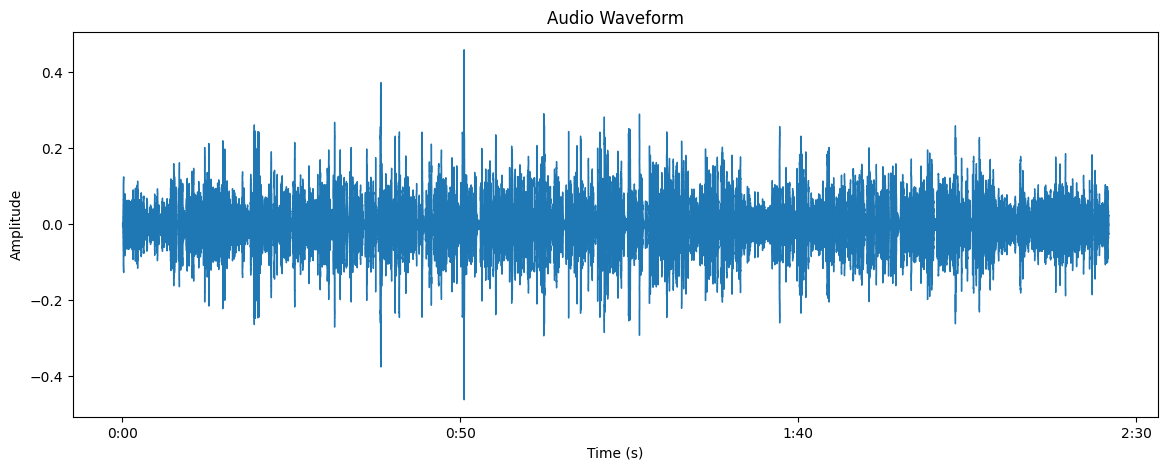

In [ ]:
plt.figure(figsize=[14,5])
librosa.display.waveshow(y,sr=sr)
# plt.xlim(0, 30)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Audio Waveform')
plt.show()

In [ ]:
!pip install -q silero-vad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.4 MB/s eta 0:00:00


In [ ]:
!pip install -q torchaudio

In [ ]:
!pip install torchcodec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 71.6 MB/s eta 0:00:00


In [ ]:
from silero_vad import (load_silero_vad,
                          read_audio,
                          get_speech_timestamps,
                          save_audio,
                          VADIterator,
                          collect_chunks)

In [ ]:

import torch
torch.set_num_threads(1)
USE_ONNX = False # change this to True if you want to test onnx model
model, utils = torch.hub.load(repo_or_dir='snakers4/silero-vad',
                                model='silero_vad',
                                force_reload=True,
                                onnx=USE_ONNX,
                                opset_version=16)

/usr/local/lib/python3.12/dist-packages/torch/hub.py:335: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip


In [ ]:
from pprint import pprint

In [ ]:
import soundfile as sf

with sf.SoundFile("your_audio_file_location") as f:
    print(f.format, f.samplerate, f.channels)

LibsndfileError: Error opening '/content/drive/MyDrive/Colab Notebooks/my_audio/audio_000028.mp3': System error.

In [ ]:

SAMPLING_RATE = 16000

wav = read_audio('your_audio_file_location/audio_file', sampling_rate=SAMPLING_RATE)
# get speech timestamps from full audio file
speech_timestamps = get_speech_timestamps(wav, model, sampling_rate=SAMPLING_RATE, return_seconds=False,
                                          speech_pad_ms=200, min_speech_duration_ms=1000,
                                          max_speech_duration_s=30)
pprint(speech_timestamps)



[{'end': 479488, 'start': 2432},
 {'end': 953600, 'start': 479488},
 {'end': 1097984, 'start': 953600},
 {'end': 1143424, 'start': 1097984}]


In [ ]:
sr = SAMPLING_RATE

for i, seg in enumerate(speech_timestamps):
    start_s = seg["start"] / sr
    end_s   = seg["end"] / sr
    dur_s   = (seg["end"] - seg["start"]) / sr
    print(f"{i}: {start_s:.2f}s → {end_s:.2f}s  (dur {dur_s:.2f}s)")

0: 0.15s → 29.97s  (dur 29.82s)
1: 29.97s → 59.60s  (dur 29.63s)
2: 59.60s → 68.62s  (dur 9.02s)
3: 68.62s → 71.46s  (dur 2.84s)


In [ ]:

for i,seg in enumerate(speech_timestamps):
  print(seg['start'], seg['end'])
  sliced_audio_data=wav[seg['start']:seg['end']]
  sf.write(f'your_audio_file_location/sliced_audio_{i}.mp3',sliced_audio_data,16000)

2432 479488
479488 953600
953600 1097984
1097984 1143424


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from IPython.display import Audio

In [ ]:
# merge all speech chunks to one audio
save_audio('only_speech.mp3',
           collect_chunks(speech_timestamps, wav), sampling_rate=SAMPLING_RATE)


**Renaming audio files**

In [ ]:
import os

folder = 'your_audio_file_location'
count = 0
for filename in os.listdir(folder):

  source = folder + filename
  destination = folder +"insurance_audio_ms_MY_"+str(count)+".mp3"
  os.rename(source, destination)
  count += 1

print('All Files Renamed')

print('New Names are')
# verify the result
res = os.listdir(folder)
print(res)


All Files Renamed
New Names are
['insurance_audio_ms_MY_0.mp3', 'insurance_audio_ms_MY_1.mp3', 'insurance_audio_ms_MY_2.mp3', 'insurance_audio_ms_MY_3.mp3', 'insurance_audio_ms_MY_4.mp3', 'insurance_audio_ms_MY_5.mp3', 'insurance_audio_ms_MY_6.mp3', 'insurance_audio_ms_MY_7.mp3', 'insurance_audio_ms_MY_8.mp3', 'insurance_audio_ms_MY_9.mp3', 'insurance_audio_ms_MY_10.mp3', 'insurance_audio_ms_MY_11.mp3', 'insurance_audio_ms_MY_12.mp3', 'insurance_audio_ms_MY_13.mp3', 'insurance_audio_ms_MY_14.mp3', 'insurance_audio_ms_MY_15.mp3', 'insurance_audio_ms_MY_16.mp3', 'insurance_audio_ms_MY_17.mp3', 'insurance_audio_ms_MY_18.mp3', 'insurance_audio_ms_MY_19.mp3', 'insurance_audio_ms_MY_20.mp3', 'insurance_audio_ms_MY_21.mp3', 'insurance_audio_ms_MY_22.mp3', 'insurance_audio_ms_MY_23.mp3', 'insurance_audio_ms_MY_24.mp3', 'insurance_audio_ms_MY_25.mp3', 'insurance_audio_ms_MY_26.mp3', 'insurance_audio_ms_MY_27.mp3', 'insurance_audio_ms_MY_28.mp3', 'insurance_audio_ms_MY_29.mp3', 'insurance_audio_

In [ ]:
# Validate if audio is working fine
Audio('your_audio_file_location/file_name')